# 🔬 ML Baseline — Classification CXR (4 classes)

**Objectif** : Tester des modèles de Machine Learning classiques sur le dataset de radiographies thoraciques (COVID, Lung Opacity, Normal, Viral Pneumonia) en ajoutant **progressivement** des étapes de preprocessing pour mesurer leur impact.

**Architecture du notebook** :
1. **Configuration** : choix des modèles, du preprocessing et de l'extraction de features
2. **Chargement** des images depuis le dataset masqué ou non
3. **Preprocessing** : fonctions modulaires (normalisation, CLAHE, flou, etc.)
4. **Extraction de features** : pixels bruts, HOG, LBP, histogramme, ou combiné
5. **Expériences** : chaque expérience ajoute une étape de preprocessing supplémentaire
6. **Comparaison** : tableau récapitulatif + heatmaps + matrices de confusion

In [28]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from time import time

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.decomposition import PCA
from skimage.feature import hog, local_binary_pattern
from skimage.exposure import equalize_adapthist # CLAHE
import cv2

import warnings
warnings.filterwarnings("ignore")

print("✅ Imports OK")

✅ Imports OK


---
## ⚙️ 1. Configuration

**Modifiez cette cellule** pour choisir :
- Les **modèles** à entraîner (commenter/décommenter)
- La **taille** des images (plus petit = plus rapide)
- Le nombre max d'images **par classe** (échantillonnage)
- La méthode d'**extraction de features**
- Les **expériences** de preprocessing (liste cumulative d'étapes)

In [29]:
# ════════════════════════════════════════════════════════════
#  CONFIGURATION — Modifier ici selon vos besoins
# ════════════════════════════════════════════════════════════


RANDOM_STATE = 42

# --- Chemin du dataset ---
DATA_DIR = Path("../data/processed/unmasked_full_dataset_256_256_L")
CLASSES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

# --- Modèles à tester (commenter/décommenter) ---
# ⚠️ class_weight='balanced' compense le déséquilibre :
#    Normal=10192 (48%), Viral Pneumonia=1345 (6%) → sans ça le modèle favorise Normal
MODELS = {
    "Random Forest":      RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    # "SVM (RBF)":          SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=RANDOM_STATE),
    # "SVM (Linear)":       SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=RANDOM_STATE),
    # "KNN (k=5)":          KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    # "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    # "Decision Tree":      DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    # "Gradient Boosting":  GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

# --- Taille de redimensionnement ---
# (64, 64) : rapide (~4K features en flatten)
# (128, 128) : meilleur compromis
# (256, 256) : qualité max mais lent avec SVM/KNN
IMG_SIZE = (128, 128)

# --- Échantillonnage par classe ---
# None = toutes les images (21K+, peut être très lent)
# 500 = bon compromis pour des tests rapides
MAX_SAMPLES_PER_CLASS = None

# --- Méthode d'extraction de features ---
# "flatten"    : pixels bruts aplatis (simple, rapide)
# "hog"        : Histogram of Oriented Gradients (contours & structures)
# "lbp"        : Local Binary Patterns (micro-textures)
# "histogram"  : histogramme d'intensité des pixels
# "combined"   : HOG + LBP + histogramme concaténés
# "pca"        : PCA sur pixels aplatis (réduction de dimensionnalité)
FEATURE_METHOD = "combined"

# --- Paramètres PCA (si FEATURE_METHOD = "pca") ---
PCA_N_COMPONENTS = 100

# --- Expériences de preprocessing (cumulatif) ---
# Étapes disponibles : "normalize", "clahe", "gaussian_blur", "histogram_eq"
PREPROCESSING_EXPERIMENTS = [
    [],                                      # Exp 0 : Baseline (aucun preprocessing)
    ["normalize"],                           # Exp 1 : + Normalisation [0,1]
    ["normalize", "gaussian_blur"],          # Exp 2 : + Flou gaussien (débruitage doux)
    ["normalize", "clahe"],                  # Exp 3 : + CLAHE (contraste adaptatif)
    ["normalize", "gaussian_blur", "clahe"], # Exp 4 : débruitage PUIS CLAHE (ordre logique)
]

# --- Split train/test ---
TEST_SIZE = 0.2


print(f"Modèles sélectionnés : {list(MODELS.keys())}")
print(f"Taille images : {IMG_SIZE}")
print(f"Max samples/classe : {MAX_SAMPLES_PER_CLASS or 'Toutes'}")
print(f"Features : {FEATURE_METHOD}")
print(f"Nombre d'expériences : {len(PREPROCESSING_EXPERIMENTS)}")
print(f"\nDistribution classes (déséquilibre à surveiller) :")
print(f"  COVID: 3616 | Lung_Opacity: 6012 | Normal: 10192 | Viral Pneumonia: 1345")

Modèles sélectionnés : ['Random Forest']
Taille images : (128, 128)
Max samples/classe : Toutes
Features : combined
Nombre d'expériences : 5

Distribution classes (déséquilibre à surveiller) :
  COVID: 3616 | Lung_Opacity: 6012 | Normal: 10192 | Viral Pneumonia: 1345


---
## 📂 2. Chargement des données

In [30]:
def load_dataset(data_dir, classes, max_per_class=None, img_size=(64, 64)):
    """Charge les images CXR depuis les sous-dossiers de classe."""
    images, labels = [], []

    for cls in classes:
        cls_dir = data_dir / cls
        files = sorted(cls_dir.glob("*.png"))

        if max_per_class is not None:
            rng = np.random.RandomState(RANDOM_STATE)
            indices = rng.choice(len(files), size=min(max_per_class, len(files)), replace=False)
            files = [files[i] for i in sorted(indices)]

        for f in tqdm(files, desc=f"  {cls}", leave=False):
            img = Image.open(f).convert("L").resize(img_size, Image.LANCZOS)
            images.append(np.array(img, dtype=np.uint8))
            labels.append(cls)

    return np.array(images), np.array(labels)


print(f"📂 Chargement depuis : {DATA_DIR}")
print(f"   Taille cible : {IMG_SIZE} | Max/classe : {MAX_SAMPLES_PER_CLASS or 'Toutes'}\n")

X_raw, y = load_dataset(DATA_DIR, CLASSES, MAX_SAMPLES_PER_CLASS, IMG_SIZE)

print(f"\n✅ Dataset chargé : {X_raw.shape[0]} images — shape {X_raw.shape[1:]}")
print(f"   Distribution :")
for cls in CLASSES:
    print(f"     {cls}: {np.sum(y == cls)}")

📂 Chargement depuis : ../data/processed/unmasked_full_dataset_256_256_L
   Taille cible : (128, 128) | Max/classe : Toutes



  COVID:   0%|          | 0/3616 [00:00<?, ?it/s]


✅ Dataset chargé : 21165 images — shape (128, 128)
   Distribution :
     COVID: 3616
     Lung_Opacity: 6012
     Normal: 10192
     Viral Pneumonia: 1345


---
## 🧹 3. Fonctions de preprocessing

Chaque fonction prend un array d'images et renvoie les images transformées.  
On peut les combiner dans n'importe quel ordre via `PREPROCESSING_EXPERIMENTS`.

In [31]:
def preprocess_normalize(images):
    """Normalise les pixels dans [0, 1]."""
    return images.astype(np.float64) / 255.0


def preprocess_clahe(images):
    """CLAHE — améliore le contraste local (adaptatif)."""
    result = []
    for img in images:
        if img.max() <= 1.0 and img.dtype in (np.float32, np.float64):
            # skimage equalize_adapthist attend float [0, 1]
            result.append(equalize_adapthist(img, clip_limit=0.03))
        else:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            result.append(clahe.apply(img.astype(np.uint8)))
    return np.array(result)


def preprocess_gaussian_blur(images, ksize=3):
    """Flou gaussien — réduit le bruit haute fréquence."""
    result = []
    for img in images:
        if img.dtype in (np.float32, np.float64):
            result.append(cv2.GaussianBlur(img, (ksize, ksize), 0))
        else:
            result.append(cv2.GaussianBlur(img.astype(np.uint8), (ksize, ksize), 0))
    return np.array(result)


def preprocess_histogram_eq(images):
    """Égalisation d'histogramme globale."""
    result = []
    for img in images:
        if img.max() <= 1.0 and img.dtype in (np.float32, np.float64):
            img_u8 = (img * 255).astype(np.uint8)
            result.append(cv2.equalizeHist(img_u8).astype(np.float64) / 255.0)
        else:
            result.append(cv2.equalizeHist(img.astype(np.uint8)))
    return np.array(result)


# Registre des étapes disponibles
PREPROCESSING_REGISTRY = {
    "normalize":    preprocess_normalize,
    "clahe":        preprocess_clahe,
    "gaussian_blur": preprocess_gaussian_blur,
    "histogram_eq": preprocess_histogram_eq,
}


def apply_preprocessing(images, steps):
    """Applique séquentiellement les étapes de preprocessing."""
    result = images.copy()
    for step_name in steps:
        result = PREPROCESSING_REGISTRY[step_name](result)
    return result


print(f"Étapes disponibles : {list(PREPROCESSING_REGISTRY.keys())}")

Étapes disponibles : ['normalize', 'clahe', 'gaussian_blur', 'histogram_eq']


---
## 🧬 4. Extraction de features

| Méthode | Description | Nb features (64×64) |
|---------|-------------|--------------------|
| `flatten` | Pixels bruts aplatis | 4 096 |
| `hog` | Contours & structures (HOG) | ~1 764 |
| `lbp` | Micro-textures (LBP) | 26 |
| `histogram` | Distribution d'intensité | 64 |
| `combined` | HOG + LBP + histogram | ~1 854 |
| `pca` | PCA sur pixels (réduction dim.) | configurable (défaut: 100) |

In [32]:
def extract_flatten(images):
    """Aplatit les images en vecteurs 1D."""
    return images.reshape(len(images), -1).astype(np.float64)


def extract_hog_features(images):
    """HOG — capture les contours et structures locales."""
    features = []
    for img in images:
        img_f = img.astype(np.float64)
        if img_f.max() > 1.0:
            img_f /= 255.0
        feat = hog(img_f, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), feature_vector=True)
        features.append(feat)
    return np.array(features)


def extract_lbp_features(images, P=24, R=3):
    """LBP — capture les micro-textures (histogramme)."""
    n_bins = P + 2
    features = []
    for img in images:
        img_u8 = img if img.dtype == np.uint8 else (img * 255).astype(np.uint8)
        lbp = local_binary_pattern(img_u8, P=P, R=R, method="uniform")
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
        features.append(hist)
    return np.array(features)


def extract_histogram_features(images, n_bins=64):
    """Histogramme d'intensité des pixels."""
    features = []
    for img in images:
        vmax = 1.0 if (img.max() <= 1.0 and img.dtype in (np.float32, np.float64)) else 256
        hist, _ = np.histogram(img.ravel(), bins=n_bins, range=(0, vmax), density=True)
        features.append(hist)
    return np.array(features)


def extract_combined_features(images):
    """Concatène HOG + LBP + histogramme."""
    return np.hstack([
        extract_hog_features(images),
        extract_lbp_features(images),
        extract_histogram_features(images),
    ])


def extract_pca_features(images, n_components=None):
    """PCA — réduction de dimensionnalité sur pixels aplatis.
    
    Fit le PCA sur les données fournies. Le nombre de composantes
    est contrôlé par PCA_N_COMPONENTS dans la config.
    """
    n_comp = n_components or PCA_N_COMPONENTS
    X_flat = images.reshape(len(images), -1).astype(np.float64)
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_flat)
    variance_explained = pca.explained_variance_ratio_.sum()
    print(f"      PCA: {X_flat.shape[1]} → {X_pca.shape[1]} features "
          f"({variance_explained:.1%} variance expliquée)")
    return X_pca


FEATURE_REGISTRY = {
    "flatten":   extract_flatten,
    "hog":       extract_hog_features,
    "lbp":       extract_lbp_features,
    "histogram": extract_histogram_features,
    "combined":  extract_combined_features,
    "pca":       extract_pca_features,
}

print(f"Méthode sélectionnée : {FEATURE_METHOD}")

Méthode sélectionnée : combined


---
## 🚀 5. Exécution des expériences

Pour chaque expérience de preprocessing, on :
1. Applique les étapes de preprocessing
2. Extrait les features
3. Split train/test stratifié
4. Scale les features (StandardScaler)
5. Entraîne chaque modèle sélectionné
6. Évalue (accuracy, F1 weighted)

In [ ]:
from copy import deepcopy


def run_experiment(X_raw, y, preprocess_steps, feature_method, models,
                   test_size=0.2, random_state=42):
    """Exécute une expérience complète : preprocessing → features → modèles."""

    # 1. Preprocessing
    t0 = time()
    X_processed = apply_preprocessing(X_raw, preprocess_steps)
    t_pp = time() - t0

    # 2. Feature extraction
    t0 = time()
    X_features = FEATURE_REGISTRY[feature_method](X_processed)
    t_feat = time() - t0

    # 3. Encode labels + split
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_enc, test_size=test_size,
        random_state=random_state, stratify=y_enc,
    )

    # 4. Scaling
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # 5. Train & evaluate
    results = {}
    for name, model_template in models.items():
        model = deepcopy(model_template)
        t0 = time()
        model.fit(X_train_s, y_train)
        t_train = time() - t0

        y_pred  = model.predict(X_test_s)
        acc     = accuracy_score(y_test, y_pred)
        f1_w    = f1_score(y_test, y_pred, average="weighted")
        f1_m    = f1_score(y_test, y_pred, average="macro")   # plus sévère sur les classes rares
        cm      = confusion_matrix(y_test, y_pred)
        report  = classification_report(y_test, y_pred,
                                        target_names=le.classes_, output_dict=True)

        results[name] = {
            "accuracy":    acc,
            "f1_weighted": f1_w,
            "f1_macro":    f1_m,
            "confusion_matrix": cm,
            "report":      report,
            "train_time":  t_train,
            "model":       model,       # conservé pour feature importance
        }
        print(f"    {name:25s}  acc={acc:.4f}  f1_w={f1_w:.4f}  f1_macro={f1_m:.4f}  ({t_train:.1f}s)")

    return results, le.classes_, t_pp, t_feat


# ── Lancement ──
all_results = {}

for i, steps in enumerate(PREPROCESSING_EXPERIMENTS):
    exp_label = " → ".join(steps) if steps else "Baseline (raw)"
    exp_name = f"Exp {i}: {exp_label}"
    print(f"\n{'═' * 75}")
    print(f"  {exp_name}")
    print(f"{'═' * 75}")

    results, class_names, t_pp, t_feat = run_experiment(
        X_raw, y, steps, FEATURE_METHOD, MODELS, TEST_SIZE, RANDOM_STATE,
    )
    all_results[exp_name] = {
        "results": results, "steps": steps,
        "t_preprocess": t_pp, "t_features": t_feat,
    }

print(f"\n✅ {len(PREPROCESSING_EXPERIMENTS)} expériences terminées !")


═══════════════════════════════════════════════════════════════════════════
  Exp 0: Baseline (raw)
═══════════════════════════════════════════════════════════════════════════


---
## 📊 6. Tableau comparatif

In [21]:
rows = []
for exp_name, exp_data in all_results.items():
    for model_name, metrics in exp_data["results"].items():
        rows.append({
            "Expérience":     exp_name,
            "Modèle":         model_name,
            "Accuracy":       metrics["accuracy"],
            "F1 (weighted)":  metrics["f1_weighted"],
            "F1 (macro)":     metrics["f1_macro"],    # pénalise les mauvaises perfs sur classes rares
            "Temps train (s)": metrics["train_time"],
        })

df_results = pd.DataFrame(rows)

print("═" * 90)
print("  TABLEAU COMPARATIF — tous modèles × toutes expériences")
print("  ⚠️  F1 macro = moyenne non pondérée : plus révélateur sur dataset déséquilibré")
print("═" * 90)

styled = df_results.style.format({
    "Accuracy":       "{:.4f}",
    "F1 (weighted)":  "{:.4f}",
    "F1 (macro)":     "{:.4f}",
    "Temps train (s)": "{:.1f}",
}).highlight_max(
    subset=["Accuracy", "F1 (weighted)", "F1 (macro)"], color="#90EE90"
).highlight_min(
    subset=["F1 (macro)"], color="#FFCCCC"
)
display(styled)

══════════════════════════════════════════════════════════════════════════════════════════
  TABLEAU COMPARATIF — tous modèles × toutes expériences
  ⚠️  F1 macro = moyenne non pondérée : plus révélateur sur dataset déséquilibré
══════════════════════════════════════════════════════════════════════════════════════════


,Expérience,Modèle,Accuracy,F1 (weighted),F1 (macro),Temps train (s)
0,Exp 0: Baseline (raw),Random Forest,0.7973,0.7924,0.7859,25.6
1,Exp 1: normalize,Random Forest,0.7973,0.7924,0.7859,29.1
2,Exp 2: normalize → gaussian_blur,Random Forest,0.8046,0.7992,0.7911,33.8
3,Exp 3: normalize → clahe,Random Forest,0.7562,0.7415,0.7234,32.9
4,Exp 4: normalize → gaussian_blur → clahe,Random Forest,0.7425,0.7211,0.6967,32.7


---
## 🔥 7. Heatmaps : Accuracy & F1 par expérience × modèle

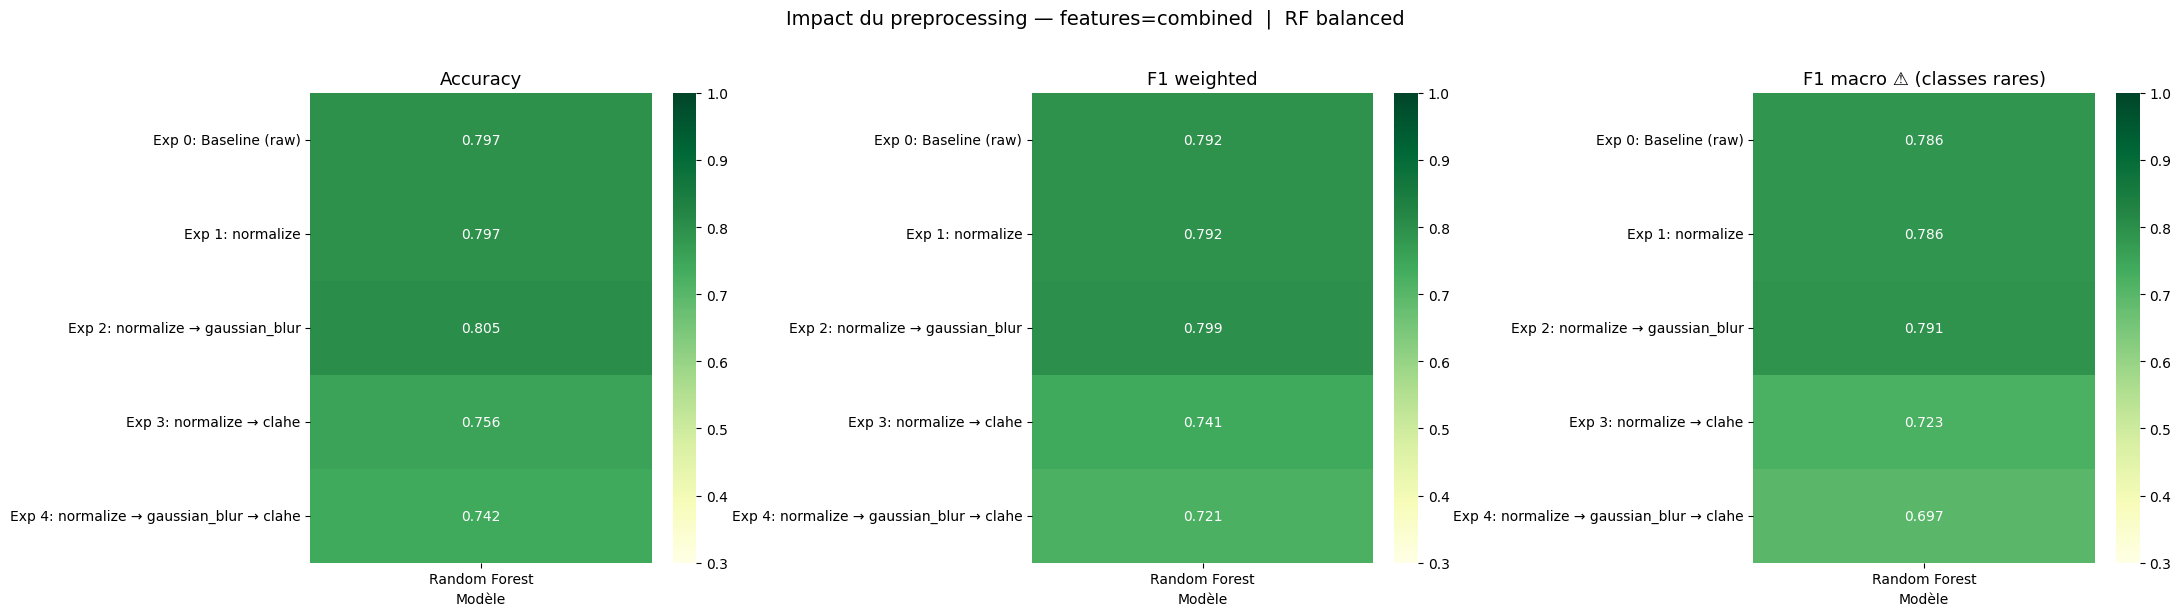

In [22]:
pivot_acc  = df_results.pivot(index="Expérience", columns="Modèle", values="Accuracy")
pivot_f1w  = df_results.pivot(index="Expérience", columns="Modèle", values="F1 (weighted)")
pivot_f1m  = df_results.pivot(index="Expérience", columns="Modèle", values="F1 (macro)")

n_rows = max(5, len(PREPROCESSING_EXPERIMENTS) * 1.2)
fig, axes = plt.subplots(1, 3, figsize=(22, n_rows))

for ax, pivot, title in zip(axes,
                             [pivot_acc, pivot_f1w, pivot_f1m],
                             ["Accuracy", "F1 weighted", "F1 macro"]):
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn",
                ax=ax, vmin=0.3, vmax=1)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("")

axes[2].set_title("F1 macro ⚠️ (classes rares)", fontsize=13)

plt.suptitle(f"Impact du preprocessing — features={FEATURE_METHOD}  |  RF balanced",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 🏆 8. Analyse du meilleur modèle

🏆 Meilleure combinaison (critère : F1 macro) :
   Modèle     : Random Forest
   Expérience : Exp 2: normalize → gaussian_blur
   Accuracy   : 0.8046
   F1 weighted: 0.7992
   F1 macro   : 0.7911


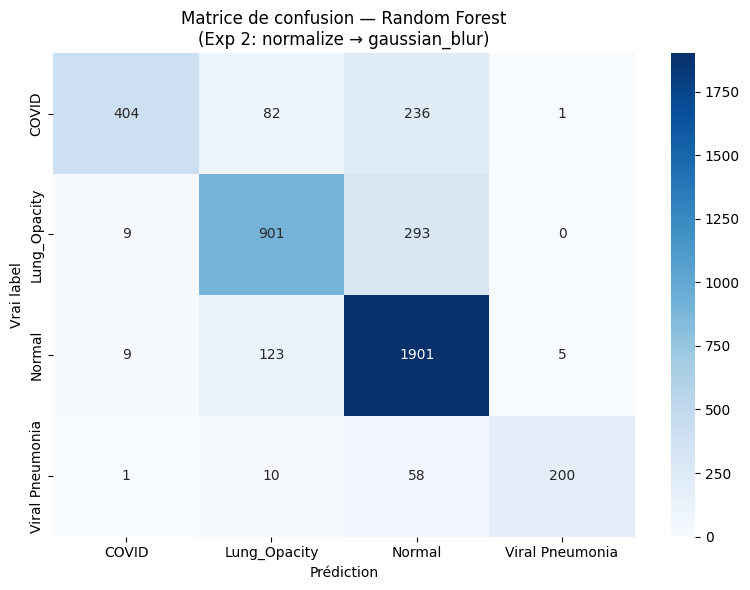


Classification Report :


,precision,recall,f1-score,support
COVID,0.955,0.559,0.705,723.000000
Lung_Opacity,0.807,0.749,0.777,1203.000000
Normal,0.764,0.933,0.840,2038.000000
Viral Pneumonia,0.971,0.743,0.842,269.000000
accuracy,0.805,0.805,0.805,0.804630
macro avg,0.874,0.746,0.791,4233.000000
weighted avg,0.822,0.805,0.799,4233.000000


In [23]:
# Identifier la meilleure combinaison (sur F1 macro — plus robuste sur dataset déséquilibré)
best_idx = df_results["F1 (macro)"].idxmax()
best = df_results.loc[best_idx]
best_exp   = best["Expérience"]
best_model = best["Modèle"]

print(f"🏆 Meilleure combinaison (critère : F1 macro) :")
print(f"   Modèle     : {best_model}")
print(f"   Expérience : {best_exp}")
print(f"   Accuracy   : {best['Accuracy']:.4f}")
print(f"   F1 weighted: {best['F1 (weighted)']:.4f}")
print(f"   F1 macro   : {best['F1 (macro)']:.4f}")

# Matrice de confusion
cm = all_results[best_exp]["results"][best_model]["confusion_matrix"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vrai label")
ax.set_title(f"Matrice de confusion — {best_model}\n({best_exp})")
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report :")
report = all_results[best_exp]["results"][best_model]["report"]
df_report = pd.DataFrame(report).T
display(df_report.style.format("{:.3f}", subset=pd.IndexSlice[:, ["precision", "recall", "f1-score"]]))

---
## 🖼️ 9. Visualisation de l'impact du preprocessing

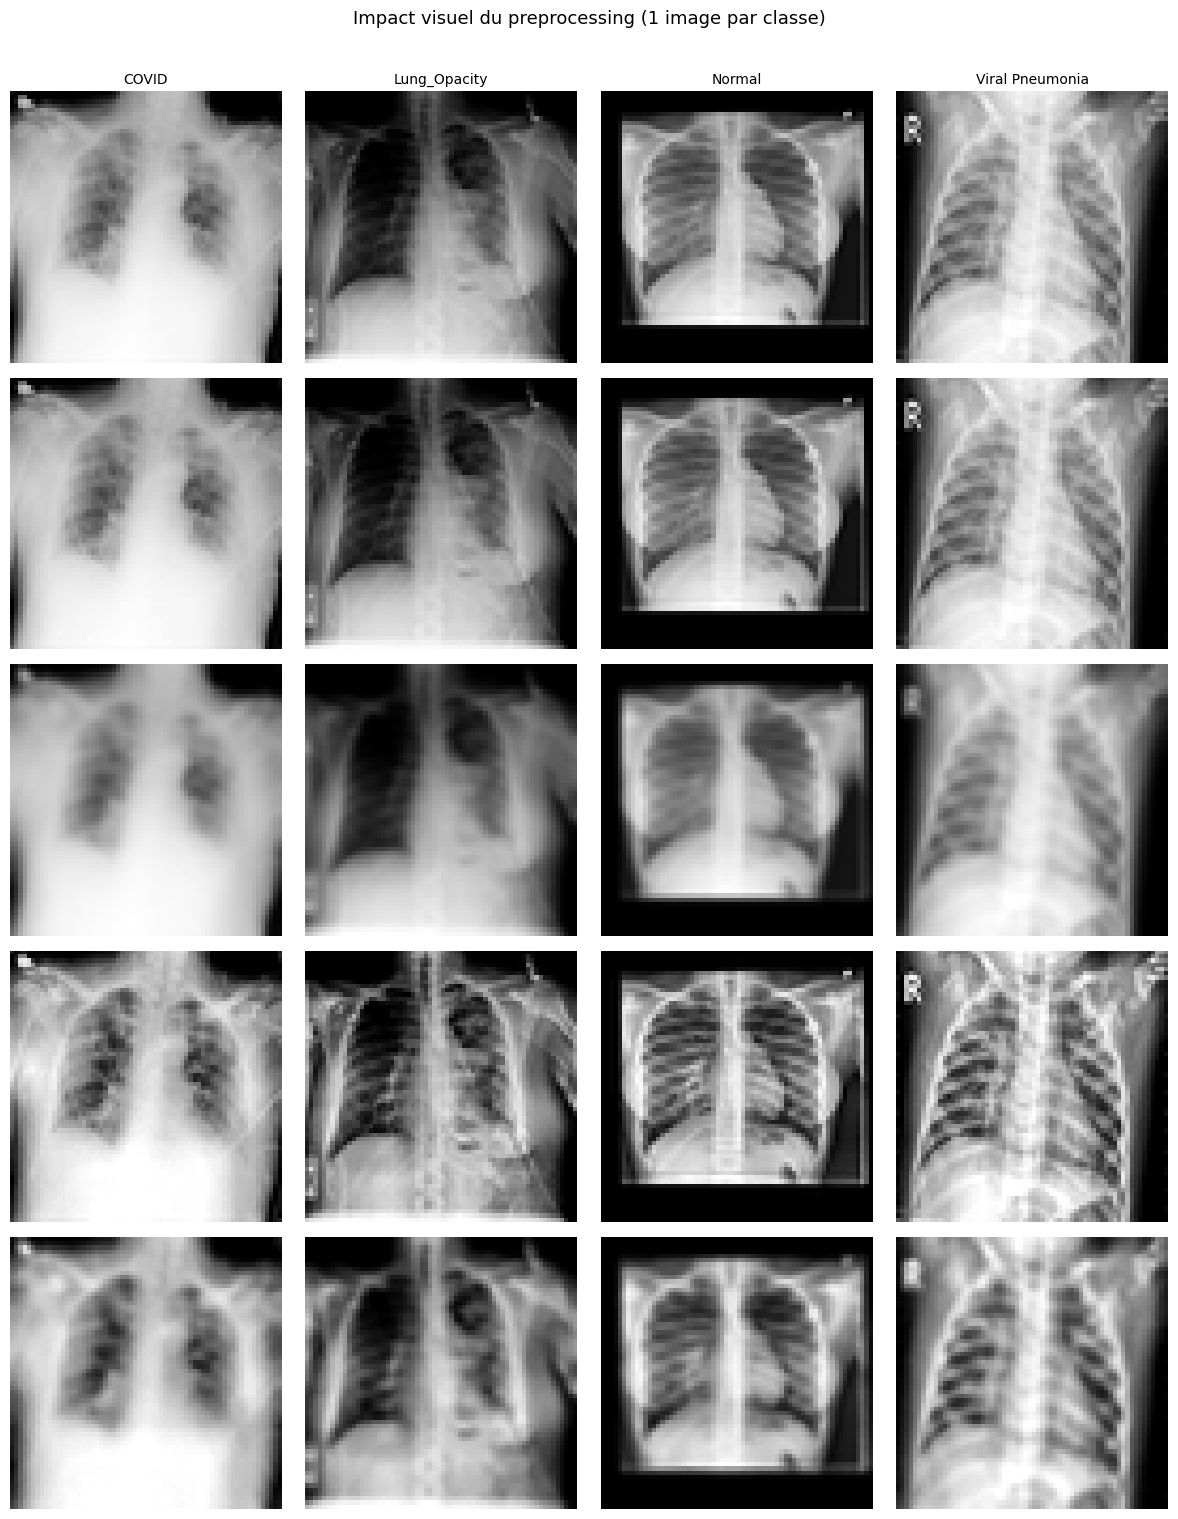

In [24]:
n_exp = len(PREPROCESSING_EXPERIMENTS)
n_cls = len(CLASSES)

fig, axes = plt.subplots(n_exp, n_cls, figsize=(3 * n_cls, 3 * n_exp))
if n_exp == 1:
    axes = axes[np.newaxis, :]

for i, steps in enumerate(PREPROCESSING_EXPERIMENTS):
    X_pp = apply_preprocessing(X_raw, steps)
    for j, cls in enumerate(CLASSES):
        idx = np.where(y == cls)[0][0]
        axes[i, j].imshow(X_pp[idx], cmap="gray")
        if i == 0:
            axes[i, j].set_title(cls, fontsize=10)
        axes[i, j].axis("off")

    label = " + ".join(steps) if steps else "Baseline"
    axes[i, 0].set_ylabel(label, fontsize=8, rotation=0, labelpad=100, va="center")

plt.suptitle("Impact visuel du preprocessing (1 image par classe)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 📈 10. Évolution des performances par modèle

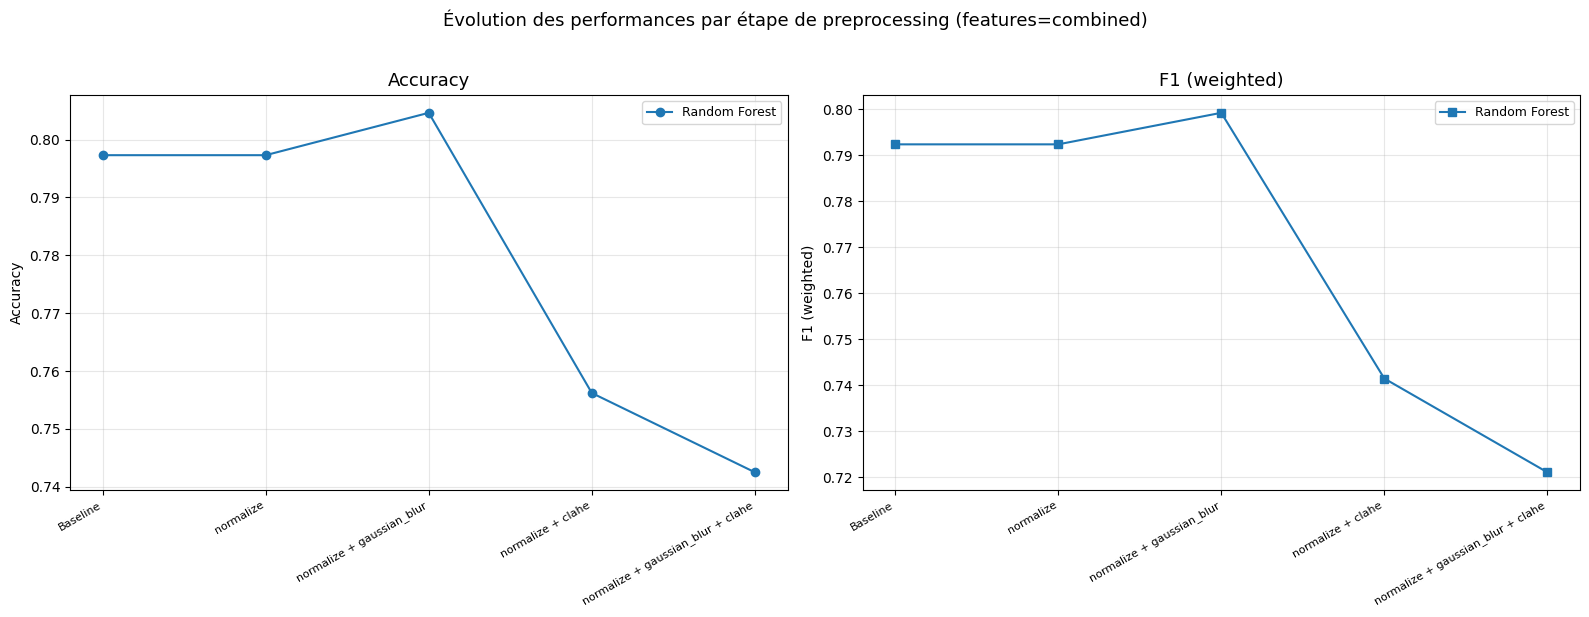

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for model_name in MODELS.keys():
    df_m = df_results[df_results["Modèle"] == model_name]
    x = range(len(df_m))
    axes[0].plot(x, df_m["Accuracy"].values, marker="o", label=model_name)
    axes[1].plot(x, df_m["F1 (weighted)"].values, marker="s", label=model_name)

exp_labels = [" + ".join(s) if s else "Baseline" for s in PREPROCESSING_EXPERIMENTS]

for ax, title in zip(axes, ["Accuracy", "F1 (weighted)"]):
    ax.set_xticks(range(len(exp_labels)))
    ax.set_xticklabels(exp_labels, rotation=30, ha="right", fontsize=8)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Évolution des performances par étape de preprocessing (features={FEATURE_METHOD})",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 🧬 11. Comparaison des méthodes d'extraction de features

On fixe ici le **meilleur preprocessing** trouvé ci-dessus et on fait varier `FEATURE_METHOD`
pour mesurer l'impact de chaque descripteur sur les performances.

| Méthode | Description | Nb features (64×64) |
|---------|-------------|---------------------|
| `flatten` | Pixels bruts aplatis | 4 096 |
| `hog` | Contours & structures (HOG) | ~1 764 |
| `lbp` | Micro-textures (LBP) | 26 |
| `histogram` | Distribution d'intensité | 64 |
| `combined` | HOG + LBP + histogram | ~1 854 |
| `pca` | PCA sur pixels (réduction dim.) | configurable |


────────────────────────────────────────────────────────────
  Feature method : flatten
────────────────────────────────────────────────────────────
    Random Forest              acc=0.8202  f1_w=0.8179  f1_macro=0.8152  (37.5s)

────────────────────────────────────────────────────────────
  Feature method : hog
────────────────────────────────────────────────────────────
    Random Forest              acc=0.7548  f1_w=0.7341  f1_macro=0.7066  (25.1s)

────────────────────────────────────────────────────────────
  Feature method : lbp
────────────────────────────────────────────────────────────
    Random Forest              acc=0.6924  f1_w=0.6843  f1_macro=0.6618  (1.9s)

────────────────────────────────────────────────────────────
  Feature method : histogram
────────────────────────────────────────────────────────────
    Random Forest              acc=0.7843  f1_w=0.7807  f1_macro=0.7612  (3.1s)

────────────────────────────────────────────────────────────
  Feature method : com

,Feature method,Modèle,Accuracy,F1 (weighted),F1 (macro),Temps train (s)
0,flatten,Random Forest,0.8202,0.8179,0.8152,37.5
1,hog,Random Forest,0.7548,0.7341,0.7066,25.1
2,lbp,Random Forest,0.6924,0.6843,0.6618,1.9
3,histogram,Random Forest,0.7843,0.7807,0.7612,3.1
4,combined,Random Forest,0.7973,0.7924,0.7859,34.4
5,pca,Random Forest,0.7241,0.7045,0.6731,7.9


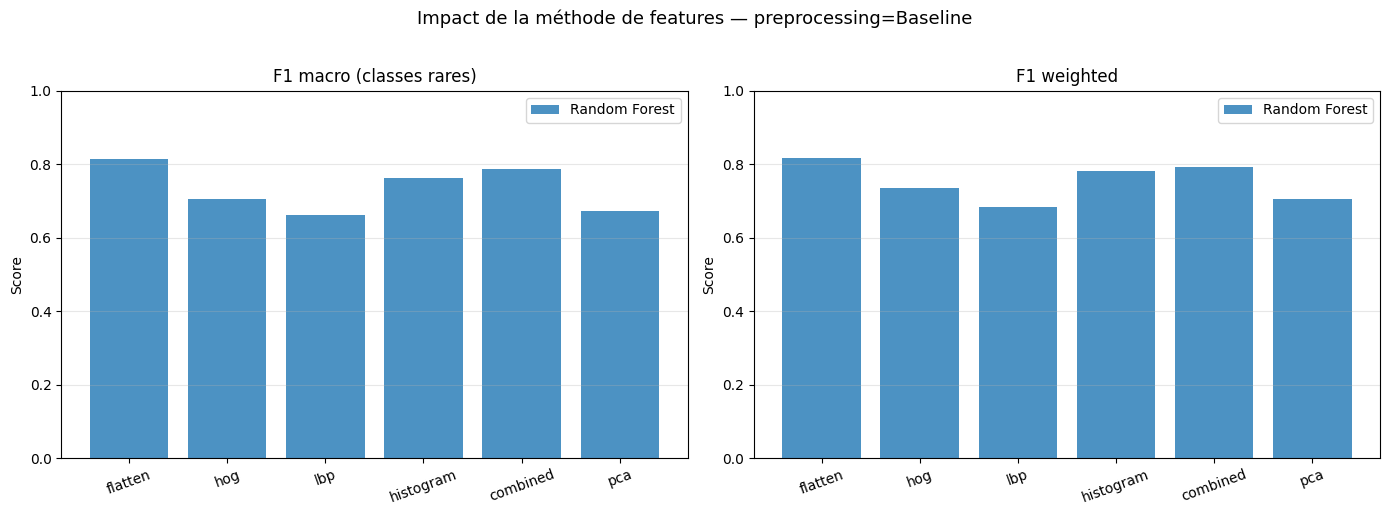

In [26]:
# ── Modifier ici selon le meilleur preprocessing trouvé ci-dessus ──
BEST_PREPROCESSING_STEPS = []   # ex: ["normalize", "gaussian_blur", "clahe"]

FEATURE_METHODS_TO_COMPARE = ["flatten", "hog", "lbp", "histogram", "combined", "pca"]

feat_results = {}

for fm in FEATURE_METHODS_TO_COMPARE:
    print(f"\n{'─' * 60}")
    print(f"  Feature method : {fm}")
    print(f"{'─' * 60}")
    results, class_names, t_pp, t_feat = run_experiment(
        X_raw, y, BEST_PREPROCESSING_STEPS, fm, MODELS, TEST_SIZE, RANDOM_STATE,
    )
    feat_results[fm] = results

# ── Tableau récapitulatif ──
feat_rows = []
for fm, res in feat_results.items():
    for model_name, metrics in res.items():
        feat_rows.append({
            "Feature method": fm,
            "Modèle":         model_name,
            "Accuracy":       metrics["accuracy"],
            "F1 (weighted)":  metrics["f1_weighted"],
            "F1 (macro)":     metrics["f1_macro"],
            "Temps train (s)": metrics["train_time"],
        })

df_feat = pd.DataFrame(feat_rows)

print("\n")
styled_feat = df_feat.style.format({
    "Accuracy":        "{:.4f}",
    "F1 (weighted)":   "{:.4f}",
    "F1 (macro)":      "{:.4f}",
    "Temps train (s)": "{:.1f}",
}).highlight_max(subset=["Accuracy", "F1 (weighted)", "F1 (macro)"], color="#90EE90") \
  .highlight_min(subset=["F1 (macro)"], color="#FFCCCC")
display(styled_feat)

# ── Graphe comparatif ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name in MODELS.keys():
    df_m = df_feat[df_feat["Modèle"] == model_name]
    axes[0].bar(df_m["Feature method"], df_m["F1 (macro)"], label=model_name, alpha=0.8)
    axes[1].bar(df_m["Feature method"], df_m["F1 (weighted)"], label=model_name, alpha=0.8)

for ax, title in zip(axes, ["F1 macro (classes rares)", "F1 weighted"]):
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Impact de la méthode de features — preprocessing={BEST_PREPROCESSING_STEPS or 'Baseline'}",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 🌲 12. Feature Importance — Random Forest

Visualise quelles features (pixels, HOG bins, LBP bins...) le RF juge les plus discriminantes.
Utile pour comprendre **sur quelles zones/structures** le modèle s'appuie.

Meilleure exp : Exp 2: normalize → gaussian_blur
Nombre de features : 1854


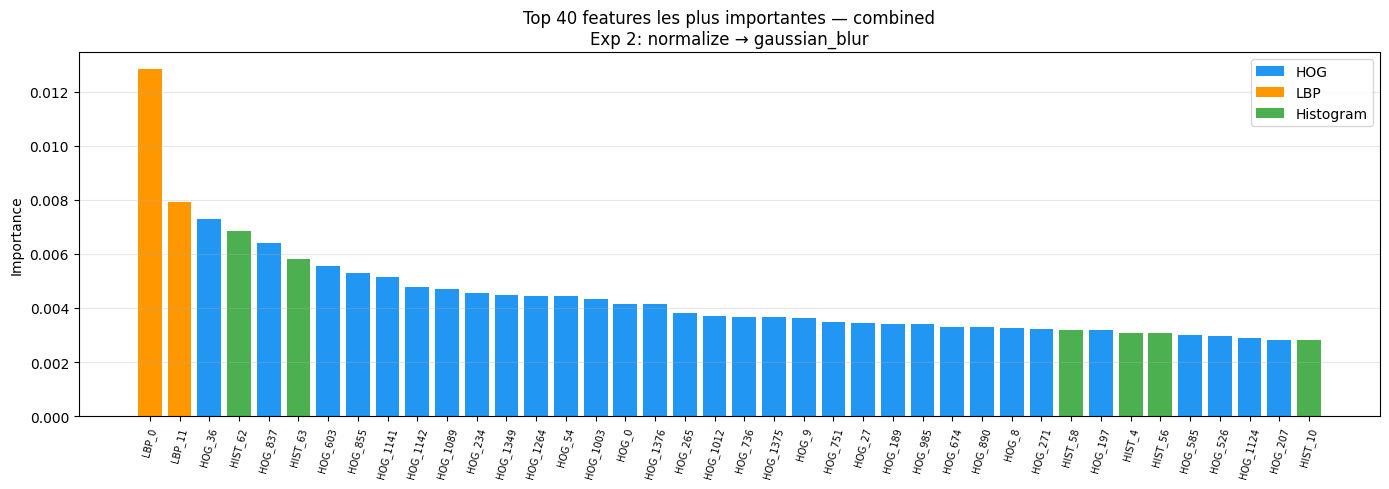

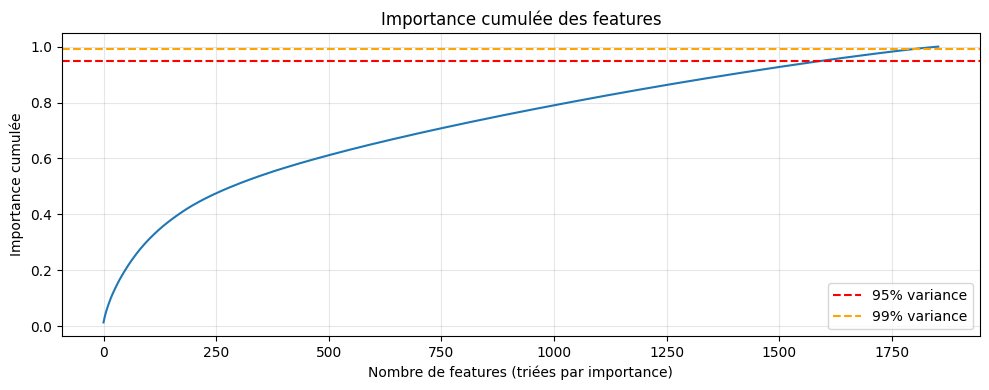


Features nécessaires pour :
  95% de l'importance cumulée : 1599 / 1854
  99% de l'importance cumulée : 1792 / 1854


In [27]:
# ── Récupère le RF de la meilleure expérience ──
best_idx  = df_results["F1 (macro)"].idxmax()
best_exp  = df_results.loc[best_idx, "Expérience"]
best_steps = all_results[best_exp]["steps"]
rf_model  = all_results[best_exp]["results"]["Random Forest"]["model"]

importances = rf_model.feature_importances_
n_features  = len(importances)
print(f"Meilleure exp : {best_exp}")
print(f"Nombre de features : {n_features}")

# ── Cas 1 : features "flatten" → on peut reshaper en carte spatiale ──
if FEATURE_METHOD == "flatten":
    imp_map = importances.reshape(IMG_SIZE)
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(imp_map, cmap="hot")
    plt.colorbar(im, ax=ax, label="Importance")
    ax.set_title(f"Carte d'importance (flatten {IMG_SIZE})\n{best_exp}", fontsize=12)
    plt.tight_layout()
    plt.show()

# ── Cas 2 : features "hog", "lbp", "histogram", "combined", "pca" → bar chart top-N ──
else:
    TOP_N = min(40, n_features)
    top_idx  = np.argsort(importances)[::-1][:TOP_N]
    top_vals = importances[top_idx]

    # Nommage des features pour "combined" (HOG + LBP + histogram)
    if FEATURE_METHOD == "combined":
        from skimage.feature import hog as _hog
        _sample = np.zeros(IMG_SIZE, dtype=np.float64)
        hog_len = len(_hog(_sample, orientations=9, pixels_per_cell=(8,8),
                           cells_per_block=(2,2), feature_vector=True))
        lbp_len = 26   # P=24 → n_bins = 26
        hist_len = 64
        feat_names = (
            [f"HOG_{i}"  for i in range(hog_len)] +
            [f"LBP_{i}"  for i in range(lbp_len)] +
            [f"HIST_{i}" for i in range(hist_len)]
        )
    else:
        feat_names = [f"feat_{i}" for i in range(n_features)]

    labels = [feat_names[i] if i < len(feat_names) else f"feat_{i}" for i in top_idx]
    colors = ["#2196F3" if "HOG" in l else "#FF9800" if "LBP" in l
              else "#4CAF50" if "HIST" in l else "#9C27B0" for l in labels]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(range(TOP_N), top_vals, color=colors)
    ax.set_xticks(range(TOP_N))
    ax.set_xticklabels(labels, rotation=75, fontsize=7)
    ax.set_ylabel("Importance")
    ax.set_title(f"Top {TOP_N} features les plus importantes — {FEATURE_METHOD}\n{best_exp}", fontsize=12)

    # Légende couleurs si combined
    if FEATURE_METHOD == "combined":
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor="#2196F3", label="HOG"),
                           Patch(facecolor="#FF9800", label="LBP"),
                           Patch(facecolor="#4CAF50", label="Histogram")]
        ax.legend(handles=legend_elements)

    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Importance cumulée
    sorted_imp = np.sort(importances)[::-1]
    cumsum = np.cumsum(sorted_imp)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(cumsum)
    ax.axhline(0.95, color="red", linestyle="--", label="95% variance")
    ax.axhline(0.99, color="orange", linestyle="--", label="99% variance")
    ax.set_xlabel("Nombre de features (triées par importance)")
    ax.set_ylabel("Importance cumulée")
    ax.set_title("Importance cumulée des features")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    n_95 = np.searchsorted(cumsum, 0.95) + 1
    n_99 = np.searchsorted(cumsum, 0.99) + 1
    print(f"\nFeatures nécessaires pour :")
    print(f"  95% de l'importance cumulée : {n_95} / {n_features}")
    print(f"  99% de l'importance cumulée : {n_99} / {n_features}")